# Decision Tree Classification

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [47]:
from sklearn.datasets import load_iris

In [48]:
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [49]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [50]:
df= pd.DataFrame(data.data,columns=data.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [51]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [52]:
x=df
y=data.target

In [53]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [54]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Train Test split

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=1)

In [56]:
x_train.shape, x_test.shape

((105, 4), (45, 4))

In [57]:
from sklearn.tree import DecisionTreeClassifier 
classifier=DecisionTreeClassifier(criterion='entropy')
classifier

DecisionTreeClassifier(criterion='entropy')

In [58]:
classifier.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

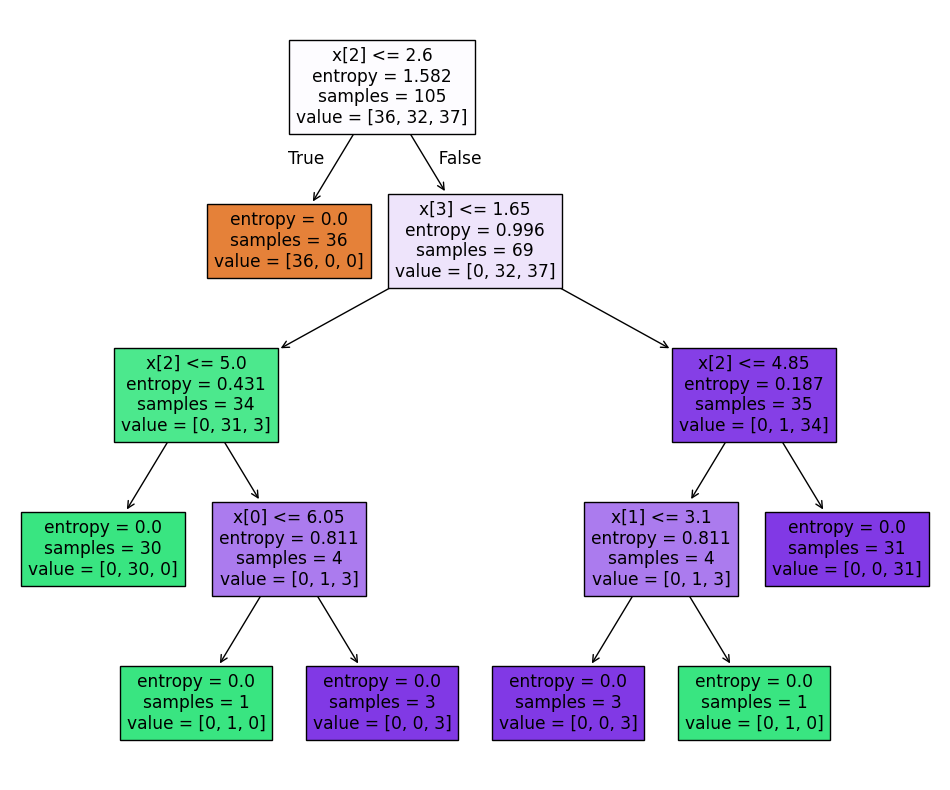

In [59]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(classifier,filled=True)
plt.show() # if we don't need to see anything then use 

In [60]:
y_pred=classifier.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 0, 1, 2,
       1])

In [61]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9555555555555556

## To Remove overfitting 3 method
### Post Purning -> After making complete decision tree we have to cut it for avoid overfitting. 

#### OBSERVATION
- Observe the decision tree plot, we will realise the last split is actually overfitting in such as way that each that each node is 100 percent pure.
- So by reducing the depth of decision tree for small dataset  

In [62]:
from sklearn.tree import DecisionTreeClassifier 

classifier=DecisionTreeClassifier(criterion='entropy', max_depth=2)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

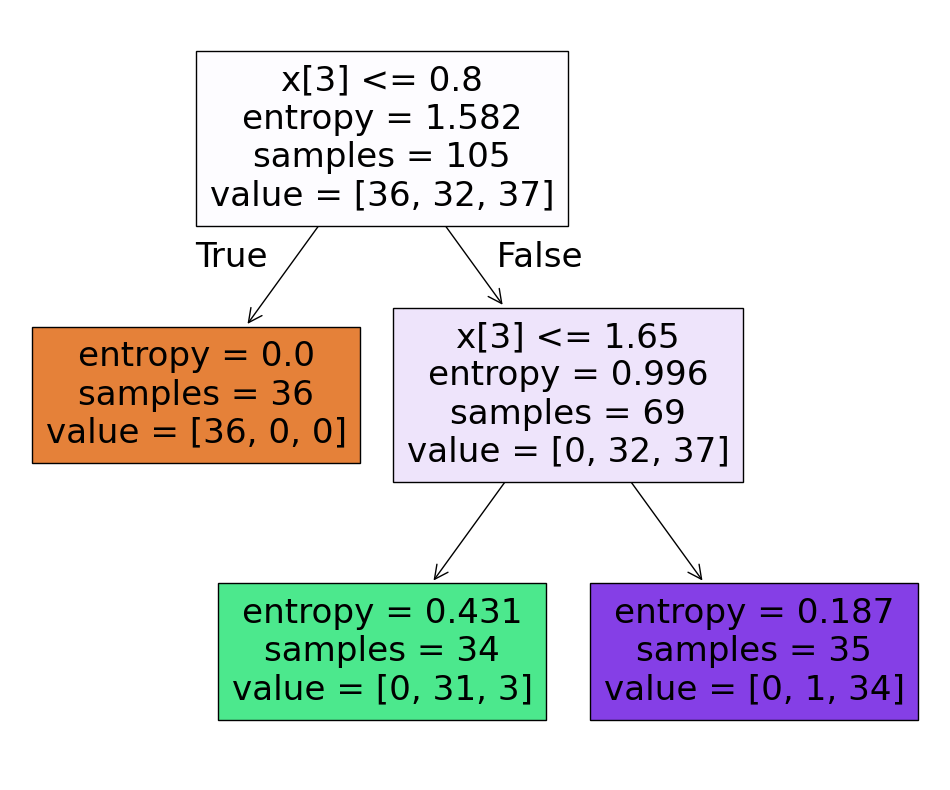

In [63]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(classifier,filled=True)
plt.show()

In [64]:
y_pred=classifier.predict(x_test)
accuracy_score(y_test, y_pred)

0.9555555555555556

In [65]:
# the accuracy is same, earlier it was a overfitting model

In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



### PrePruning using hyperparameter

In [67]:
parameter={
    'criterion':['gini','entropy','log_los'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,10],
    'max_features':['sqrt','log2','auto']
}

In [68]:
from sklearn.model_selection import GridSearchCV
clf=DecisionTreeClassifier()
model=GridSearchCV(clf, param_grid=parameter, cv=5, scoring='accuracy', verbose=3)

In [69]:
model.fit(x_train,y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=best;, score=0.714 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=best;, score=0.714 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=best;, score=0.714 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=best;, score=0.667 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=best;, score=0.667 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=random;, score=0.714 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=random;, score=0.714 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, max_features=sqrt, splitter=random;, score=0.714 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, max_features=sqrt, splitt

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_los'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 10],
                         'max_features': ['sqrt', 'log2', 'auto'],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=3)

In [70]:
model.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'max_features': 'log2',
 'splitter': 'random'}

In [71]:
model.best_score_

np.float64(0.961904761904762)

In [72]:
y_pred=model.best_estimator_.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 1, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 0, 2, 2,
       1])

In [73]:
accuracy_score(y_test, y_pred)

0.9555555555555556

# Decision Tree Regression

In [74]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [76]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df['price']=data.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [77]:
df.shape

(20640, 9)

In [78]:
df.sample(4)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
8317,2.7361,52.0,6.225000,1.650000,341.0,2.131250,33.34,-118.32,4.500
18113,6.0830,34.0,6.099768,1.004640,1301.0,3.018561,37.31,-122.02,3.414
18956,2.8438,38.0,4.779528,0.960630,632.0,2.488189,38.25,-122.04,0.942
11102,3.7772,26.0,5.412414,1.077241,2332.0,3.216552,33.85,-117.88,2.239


In [79]:
df.sample(frac=0.20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
8175,5.7942,36.0,6.008108,1.000000,1039.0,2.808108,33.79,-118.11,2.57000
4492,10.2264,52.0,4.800000,0.600000,41.0,4.100000,34.06,-118.22,1.12500
5198,1.1468,39.0,4.123016,1.113095,1901.0,3.771825,33.94,-118.27,0.96900
20455,2.7137,7.0,4.700306,1.214067,1816.0,2.776758,34.27,-118.77,1.96400
692,2.5833,19.0,4.309154,1.096718,1571.0,2.713299,37.70,-122.12,1.59900
...,...,...,...,...,...,...,...,...,...
13128,3.2150,19.0,4.837931,0.951724,901.0,3.106897,38.26,-121.30,1.04600
7214,1.7813,34.0,3.762376,1.084158,968.0,4.792079,34.02,-118.17,1.45000
10970,4.6111,39.0,6.388633,1.006144,1669.0,2.563748,33.77,-117.86,2.40300
12778,1.6033,44.0,4.951289,1.051576,1042.0,2.985673,38.64,-121.42,0.58500


In [80]:
df.shape

(20640, 9)

In [81]:
# Seprate independent variable (x) and dependent variable (y)
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [82]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [83]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: price, Length: 20640, dtype: float64

In [84]:
# train test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [85]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train, y_train)

DecisionTreeRegressor()

In [87]:
y_pred=model.predict(x_test)
y_pred

array([4.357, 0.683, 2.296, ..., 1.667, 2.707, 0.952])

In [88]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)

0.6107137939775662

### Hyperparemeter tuning

In [104]:
params={
    'criterion':['squared_eror','absolute_error','friedman_mse','poission'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,10],
    'max_features':['auto','sqrt','log2']
}

In [105]:
regressor=DecisionTreeRegressor()

In [106]:
from sklearn.model_selection import GridSearchCV
model=GridSearchCV(regressor, param_grid=params, cv=3, scoring='neg_mean_squared_error', verbose=3)

In [107]:
model.fit(x_train,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV 1/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/3] END criterion=squared_eror, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 1/3] END criterion=squared_eror, max_depth=1, max_features=sqrt, splitter=best;, score=nan total time=   0.0s
[CV 2/3] END criterion=squared_eror, max_depth=1, max_features=sqrt, splitter=best;, score=nan total time=   0.0s
[CV 3/3] END criter

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_eror', 'absolute_error',
                                       'friedman_mse', 'poission'],
                         'max_depth': [1, 2, 3, 4, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error', verbose=3)

In [108]:
model.best_params_

{'criterion': 'absolute_error',
 'max_depth': 10,
 'max_features': 'log2',
 'splitter': 'best'}

In [109]:
final_model=DecisionTreeRegressor(criterion='absolute_error',max_depth=10, max_features='log2', splitter='best')

In [110]:
final_model.fit(x_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=10,
                      max_features='log2')

[Text(0.6189893018018018, 0.9545454545454546, 'x[6] <= 38.485\nabsolute_error = 0.886\nsamples = 16512\nvalue = 1.806'),
 Text(0.37737894144144146, 0.8636363636363636, 'x[0] <= 5.137\nabsolute_error = 0.897\nsamples = 14882\nvalue = 1.897'),
 Text(0.4981841216216216, 0.9090909090909092, 'True  '),
 Text(0.19304617117117118, 0.7727272727272727, 'x[0] <= 2.618\nabsolute_error = 0.694\nsamples = 11711\nvalue = 1.663'),
 Text(0.09149774774774774, 0.6818181818181818, 'x[2] <= 3.82\nabsolute_error = 0.524\nsamples = 3636\nvalue = 1.14'),
 Text(0.04605855855855856, 0.5909090909090909, 'x[0] <= 2.105\nabsolute_error = 0.578\nsamples = 1171\nvalue = 1.547'),
 Text(0.02668918918918919, 0.5, 'x[7] <= -117.145\nabsolute_error = 0.59\nsamples = 691\nvalue = 1.385'),
 Text(0.014414414414414415, 0.4090909090909091, 'x[3] <= 0.946\nabsolute_error = 0.612\nsamples = 606\nvalue = 1.47'),
 Text(0.007207207207207207, 0.3181818181818182, 'x[6] <= 35.295\nabsolute_error = 0.519\nsamples = 53\nvalue = 1.058'

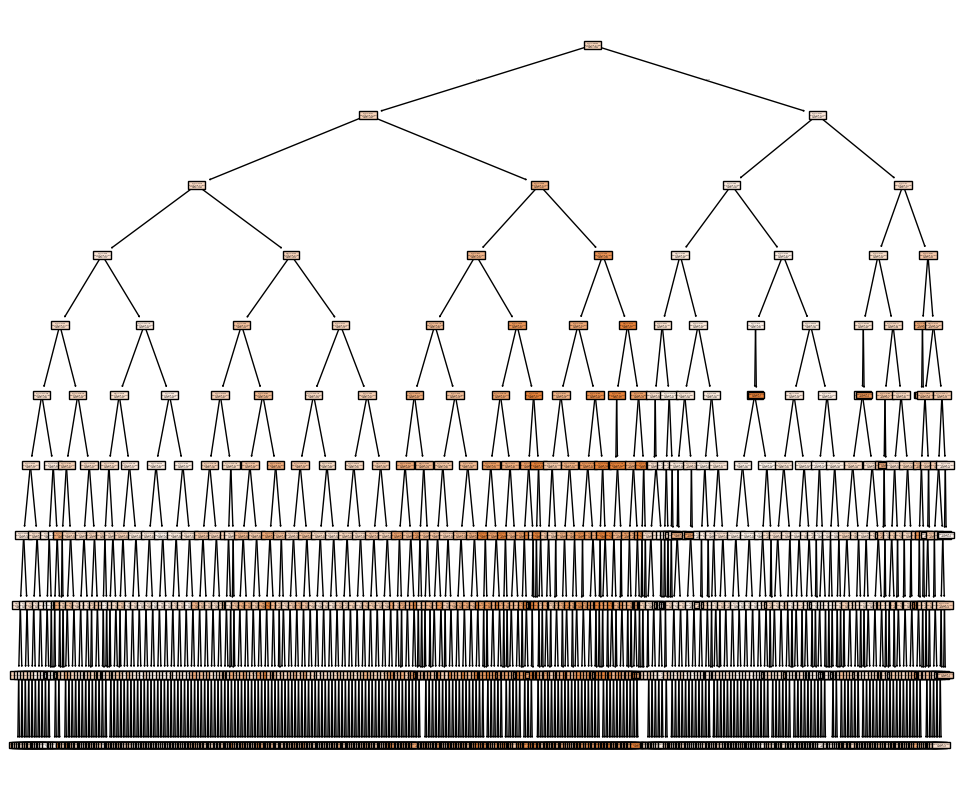

In [112]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(final_model, filled=True)

In [113]:
y_pred=model.predict(x_test)
y_pred

array([3.1125, 0.761 , 2.515 , ..., 2.698 , 2.182 , 1.1715])

In [114]:
r2_score(y_pred, y_test)

0.6166768945718468